# 09 — Task 3: Valutazione e Confronto Comparativo
## AE · VAE · Normalizing Flow · Diffusion Model vs Supervised Baseline

**Prerequisiti:** eseguire in ordine:
- `07_autoencoder_feat.ipynb` → `outputs/ae_out_feat/`
- `normalizing_flow_anomaly.ipynb` → `outputs/nf_results/` (pesi NF)
- `diffusion_model_anomaly.ipynb` → `outputs/diffusion_results/`

---

## Obiettivi (Task 3)

| # | Analisi |
|---|---|
| 1 | Distribuzioni degli anomaly score QCD vs EJ per ogni modello |
| 2 | ROC curves e AUC — confronto unsupervised vs supervised |
| 3 | Curva EJ efficiency vs QCD rejection (scala HEP) |
| 4 | Tabella riepilogativa delle metriche |
| 5 | Analisi della sensibilità al tipo di EJ |

---

## Nota sulle feature

I modelli usano input leggermente diversi, come stabilito nelle analisi di leakage:

| Gruppo | Modelli | Input dim | Feature rimosse |
|--------|---------|-----------|----------------|
| A | AE, VAE | 65 | `d0_log1p`, `radiusOfFirstHit`, `IP3D_d0_sig`, `IP3D_z0_sig`, `displacedPtFraction` (21 dim) |
| B | NF, DDPM | 85 | Solo `displacedPtFraction` (1 dim) |

Il **supervised baseline** viene calcolato per entrambi i feature set per un confronto equo.
`displacedPtFraction` è rimossa da tutti i modelli: vale 0 per tutti i QCD ed è un discriminatore banale.

## 0. Setup

In [1]:
import math, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import roc_auc_score, roc_curve, auc
from sklearn.ensemble import GradientBoostingClassifier
from pathlib import Path
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device} | PyTorch: {torch.__version__}')

Device: cpu | PyTorch: 2.11.0+cpu


## 1. Percorsi

In [2]:
BASE    = Path(r'C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs')
OUT     = BASE / 'outputs' / 'task3_comparison'
OUT.mkdir(parents=True, exist_ok=True)

EMBED_PATH    = BASE / 'outputs' / 'embeddings_preprocessed.npz'
AE_SCORES     = BASE / 'outputs' / 'ae_out_feat'       / 'test_scores.npz'
NF_MODEL      = BASE / 'outputs' / 'nf_results'        / 'realnvp_model.pt'
DDPM_SCORES   = BASE / 'outputs' / 'diffusion_results' / 'ddpm_scores.npz'
TASK3_OLD     = BASE / 'outputs' / 'task3_out'         / 'all_scores.npz'

for p, name in [(EMBED_PATH,'embeddings'), (AE_SCORES,'AE scores'),
                (NF_MODEL,'NF model'), (DDPM_SCORES,'DDPM scores')]:
    status = '✓' if p.exists() else '✗ MANCANTE'
    print(f'  {status}  {name}: {p.name}')

print(f'\nOutput: {OUT}')

  ✓  embeddings: embeddings_preprocessed.npz
  ✓  AE scores: test_scores.npz
  ✓  NF model: realnvp_model.pt
  ✓  DDPM scores: ddpm_scores.npz

Output: C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\outputs\task3_comparison


## 2. Caricamento dati e definizione feature mask

In [3]:
# ── Mappa nomi embedding 86-dim ───────────────────────────────────────────────
TRACK_FEATURES = [
    'pt_log1p', 'd0_log1p', 'z0RelativeToBeamspot', 'deta', 'dphi',
    'dr', 'ptfrac', 'qOverP', 'chiSquared', 'radiusOfFirstHit',
    'IP3D_signed_d0_significance', 'IP3D_signed_z0_significance',
    'numberOfInnermostPixelLayerHits', 'numberOfPixelHits', 'numberOfSCTHits',
]
JET_FEATURES = [
    'pt', 'eta', 'mass', 'energy', 'displacedPtFraction',
    'Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop',
    'Split12_clusterSoftDrop', 'timing_clusterSoftDrop', 'nPrimaryVertices',
]
STATS = ['mean', 'std', 'p25', 'p75', 'max']
EMB_NAMES = [f'{s}_{f}' for s in STATS for f in TRACK_FEATURES] + ['n_valid'] + JET_FEATURES
assert len(EMB_NAMES) == 86

# ── Feature mask Gruppo B: solo rimuove displacedPtFraction (dim 80) ──────────
DROP_B   = [EMB_NAMES.index('displacedPtFraction')]
MASK_B   = np.array([i for i in range(86) if i not in DROP_B])  # 85 dim

# ── Feature mask Gruppo A: caricata dal file AE (21 dim rimosse) ──────────────
ae_data  = np.load(AE_SCORES)
MASK_A   = ae_data['feat_mask']                                   # 65 dim

print(f'Embedding originale: 86 dim')
print(f'Gruppo A (AE/VAE):   {len(MASK_A)} dim  (21 rimosse: IP/d0/radius + displacedPtFraction)')
print(f'Gruppo B (NF/DDPM):  {len(MASK_B)} dim  (1 rimossa:  solo displacedPtFraction)')

Embedding originale: 86 dim
Gruppo A (AE/VAE):   65 dim  (21 rimosse: IP/d0/radius + displacedPtFraction)
Gruppo B (NF/DDPM):  85 dim  (1 rimossa:  solo displacedPtFraction)


In [4]:
# ── Caricamento embedding ─────────────────────────────────────────────────────
raw        = np.load(EMBED_PATH)
X_val_full = raw['X_val'].astype(np.float32)     # (N_val, 86)
y_val      = raw['y_val'].astype(np.int64)
X_test_full= raw['X_test'].astype(np.float32)    # (N_test, 86)
y_test     = raw['y_test'].astype(np.int64)
X_train_full = raw['X_train'].astype(np.float32) # (N_train, 86) QCD only

# Applicazione maschere
X_test_A  = np.clip(X_test_full[:, MASK_A], -5, 5)   # (N_test, 65)
X_test_B  = np.clip(X_test_full[:, MASK_B], -5, 5)   # (N_test, 85)
X_val_B   = np.clip(X_val_full[:,  MASK_B], -5, 5)
X_train_B = np.clip(X_train_full[:, MASK_B], -5, 5)  # QCD only, per supervised training
X_val_A   = np.clip(X_val_full[:,  MASK_A], -5, 5)
X_train_A = np.clip(X_train_full[:, MASK_A], -5, 5)

print(f'Test:  {X_test_full.shape[0]:,} jet  (QCD: {(y_test==0).sum():,}, EJ: {(y_test==1).sum():,})')
print(f'Val:   {X_val_full.shape[0]:,} jet  (QCD: {(y_val==0).sum():,},  EJ: {(y_val==1).sum():,})')
print(f'Train: {X_train_full.shape[0]:,} jet (QCD only)')

Test:  30,000 jet  (QCD: 5,000, EJ: 25,000)
Val:   30,000 jet  (QCD: 5,000,  EJ: 25,000)
Train: 40,000 jet (QCD only)


## 3. Caricamento score — AE e VAE

In [5]:
scores_ae  = ae_data['scores_ae'].astype(np.float32)
scores_vae = ae_data['scores_vae'].astype(np.float32)
# Verifica che le label corrispondano
assert np.array_equal(ae_data['labels'], y_test), 'Label mismatch AE!'

auc_ae  = roc_auc_score(y_test, scores_ae)
auc_vae = roc_auc_score(y_test, scores_vae)
print(f'AE  (65-dim):  AUC = {auc_ae:.4f}')
print(f'VAE (65-dim):  AUC = {auc_vae:.4f}')

AE  (65-dim):  AUC = 0.8322
VAE (65-dim):  AUC = 0.8110


## 4. Caricamento score — DDPM

In [6]:
ddpm_data   = np.load(DDPM_SCORES)
scores_ddpm = ddpm_data['npe_test'].astype(np.float32)
assert np.array_equal(ddpm_data['y_test'], y_test), 'Label mismatch DDPM!'

auc_ddpm = roc_auc_score(y_test, scores_ddpm)
print(f'DDPM NPE (85-dim):  AUC = {auc_ddpm:.4f}')

DDPM NPE (85-dim):  AUC = 0.8463


## 5. Inferenza NF — Normalizing Flow (RealNVP)

Il Normalizing Flow salva solo i pesi: ricalcoliamo gli score inline
caricando il modello con le classi definite qui sotto.

In [7]:
# ── Definizioni minimali per il caricamento del RealNVP ───────────────────────
class _MLP(nn.Module):
    def __init__(self, in_d, out_d, h, n):
        super().__init__()
        dims = [in_d] + [h]*n + [out_d]
        layers = []
        for i in range(len(dims)-1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims)-2:
                layers += [nn.LeakyReLU(0.1), nn.BatchNorm1d(dims[i+1])]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

class _AffineCouplingLayer(nn.Module):
    def __init__(self, dim, mask, h, n):
        super().__init__()
        self.register_buffer('mask', mask.float())
        d_in = int(mask.sum().item()); d_out = dim - d_in
        self.net = _MLP(d_in, 2*d_out, h, n)
        self.log_scale_factor = nn.Parameter(torch.zeros(d_out))
        self.register_buffer('idx_a', (mask==1).nonzero(as_tuple=True)[0])
        self.register_buffer('idx_b', (mask==0).nonzero(as_tuple=True)[0])
    def forward(self, x):
        xa = x[:, self.idx_a]; xb = x[:, self.idx_b]
        st = self.net(xa)
        s = torch.tanh(st[:, :xb.shape[1]]) * torch.exp(self.log_scale_factor)
        t = st[:, xb.shape[1]:]
        zb = xb * torch.exp(s) + t
        z = x.clone(); z[:, self.idx_b] = zb
        return z, s.sum(dim=1)
    def inverse(self, z):
        za = z[:, self.idx_a]; zb = z[:, self.idx_b]
        st = self.net(za)
        s = torch.tanh(st[:, :zb.shape[1]]) * torch.exp(self.log_scale_factor)
        t = st[:, zb.shape[1]:]
        xb = (zb - t) * torch.exp(-s)
        x = z.clone(); x[:, self.idx_b] = xb
        return x

class _ActNorm(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.log_scale = nn.Parameter(torch.zeros(dim))
        self.bias = nn.Parameter(torch.zeros(dim))
        self.initialized = False
    @torch.no_grad()
    def _init(self, x):
        self.bias.data = -x.mean(0)
        self.log_scale.data = -torch.log(x.std(0).clamp(min=1e-6))
        self.initialized = True
    def forward(self, x):
        if not self.initialized: self._init(x)
        z = (x + self.bias) * torch.exp(self.log_scale)
        return z, self.log_scale.sum().expand(x.shape[0])
    def inverse(self, z): return z * torch.exp(-self.log_scale) - self.bias

class RealNVP(nn.Module):
    def __init__(self, dim, n_coupling, h, n_hidden):
        super().__init__()
        self.dim = dim
        self.register_buffer('base_mean', torch.zeros(dim))
        self.register_buffer('base_var',  torch.ones(dim))
        layers = []
        for k in range(n_coupling):
            mask = (torch.arange(dim) % 2 == (k%2)).long()
            layers.append(_ActNorm(dim))
            layers.append(_AffineCouplingLayer(dim, mask, h, n_hidden))
        self.layers = nn.ModuleList(layers)
    def log_prob(self, x):
        z = x; ld = torch.zeros(x.shape[0], device=x.device)
        for layer in self.layers:
            z, l = layer(z); ld = ld + l
        log_pz = -0.5*(z.pow(2) + torch.log(torch.tensor(2*math.pi, device=x.device))).sum(1)
        return log_pz + ld


# ── Carica il modello NF ──────────────────────────────────────────────────────
nf_ckpt = torch.load(NF_MODEL, map_location='cpu', weights_only=False)
hp = nf_ckpt['hyperparams']
model_nf = RealNVP(hp['input_dim'], hp['n_coupling'], hp['hidden_dim'], hp['n_hidden'])
model_nf.load_state_dict(nf_ckpt['model_state_dict'])
model_nf = model_nf.to(device).eval()

print(f'NF caricato: {hp}')
print(f'AUC registrata nel checkpoint — val: {nf_ckpt["auc_val"]:.4f}, test: {nf_ckpt["auc_test"]:.4f}')

NF caricato: {'input_dim': 85, 'n_coupling': 8, 'hidden_dim': 256, 'n_hidden': 2}
AUC registrata nel checkpoint — val: 0.8682, test: 0.8718


In [8]:
@torch.no_grad()
def compute_nf_scores(X_np, batch_size=1024):
    model_nf.eval()
    out = []
    Xt = torch.from_numpy(X_np)
    for i in range(0, len(Xt), batch_size):
        b = Xt[i:i+batch_size].to(device)
        out.append(-model_nf.log_prob(b).cpu().numpy())
    return np.concatenate(out)

print('Calcolo NF scores sul test set...')
scores_nf = compute_nf_scores(X_test_B)   # 85-dim
auc_nf = roc_auc_score(y_test, scores_nf)
print(f'NF (85-dim):  AUC = {auc_nf:.4f}')

Calcolo NF scores sul test set...
NF (85-dim):  AUC = 0.8009


## 6. Supervised Baseline

Il modello supervisionato conosce le label durante il training — rappresenta il **limite superiore**
di performance raggiungibile. Addestriamo un Gradient Boosted Tree su:
- **Gruppo A (65-dim)**: confronto equo con AE/VAE
- **Gruppo B (85-dim)**: confronto equo con NF/DDPM

Training su `X_val` (misto QCD+EJ con label), test su `X_test`.

In [9]:
from sklearn.ensemble import GradientBoostingClassifier

def train_gbt(X_train, y_train, X_test, label=''):
    print(f'  Training GBT {label}... (n={len(X_train):,})', end=' ', flush=True)
    clf = GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                     learning_rate=0.1, subsample=0.8,
                                     random_state=SEED)
    clf.fit(X_train, y_train)
    scores = clf.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, scores)
    print(f'AUC = {auc_score:.4f}')
    return scores, auc_score

print('Supervised GBT — usa il val set come training (ha label QCD+EJ):')
scores_sup_A, auc_sup_A = train_gbt(X_val_A, y_val, X_test_A, '(65-dim)')
scores_sup_B, auc_sup_B = train_gbt(X_val_B, y_val, X_test_B, '(85-dim)')

Supervised GBT — usa il val set come training (ha label QCD+EJ):
  Training GBT (65-dim)... (n=30,000) AUC = 0.9883
  Training GBT (85-dim)... (n=30,000) AUC = 0.9885


## 7. Distribuzioni degli Anomaly Score

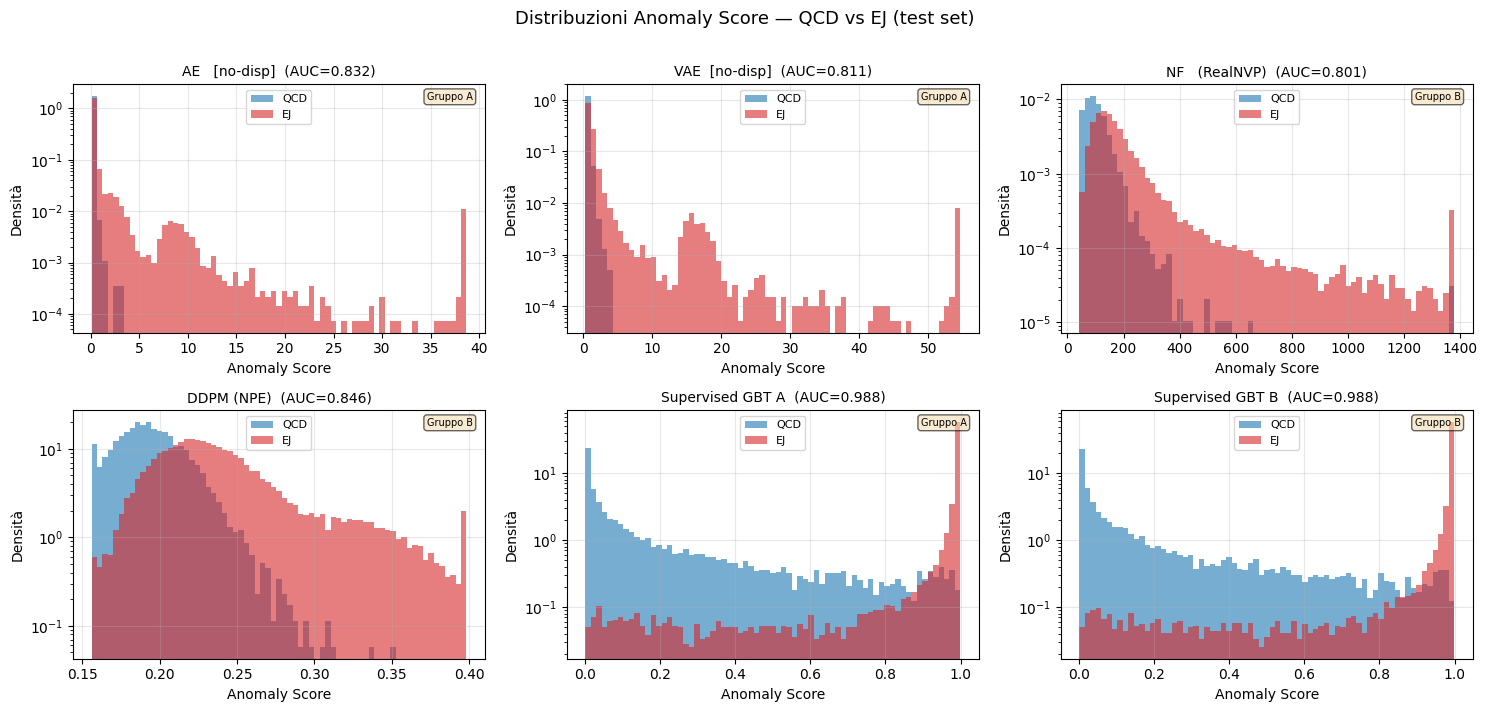

Salvato: score_distributions_all.png


In [10]:
C_QCD = '#1f77b4'
C_EJ  = '#d62728'

def plot_all_score_dists(all_models, filename):
    """Grid di istogrammi QCD vs EJ per ogni modello."""
    n = len(all_models)
    cols = 3; rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols*5, rows*3.5))
    axes = axes.flatten()

    for ax, (name, scores, group) in zip(axes, all_models):
        sq = scores[y_test == 0]
        se = scores[y_test == 1]
        lo = np.percentile(scores, 0.5)
        hi = np.percentile(scores, 99.5)
        bins = np.linspace(lo, hi, 70)
        ax.hist(np.clip(sq, lo, hi), bins=bins, density=True,
                alpha=0.6, color=C_QCD, label='QCD')
        ax.hist(np.clip(se, lo, hi), bins=bins, density=True,
                alpha=0.6, color=C_EJ,  label='EJ')
        auc_v = roc_auc_score(y_test, scores)
        ax.set_title(f'{name}  (AUC={auc_v:.3f})', fontsize=10)
        ax.set_yscale('log')
        ax.set_xlabel('Anomaly Score'); ax.set_ylabel('Densità')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
        # Tag del gruppo
        ax.text(0.97, 0.97, f'Gruppo {group}', transform=ax.transAxes,
                ha='right', va='top', fontsize=7,
                bbox=dict(boxstyle='round', fc='wheat', alpha=0.6))

    for ax in axes[len(all_models):]:
        ax.set_visible(False)

    plt.suptitle('Distribuzioni Anomaly Score — QCD vs EJ (test set)', y=1.01, fontsize=13)
    plt.tight_layout()
    plt.savefig(OUT / filename, dpi=150, bbox_inches='tight')
    plt.show()


ALL_MODELS = [
    ('AE   [no-disp]',    scores_ae,    'A'),
    ('VAE  [no-disp]',    scores_vae,   'A'),
    ('NF   (RealNVP)',    scores_nf,    'B'),
    ('DDPM (NPE)',        scores_ddpm,  'B'),
    ('Supervised GBT A', scores_sup_A, 'A'),
    ('Supervised GBT B', scores_sup_B, 'B'),
]

plot_all_score_dists(ALL_MODELS, 'score_distributions_all.png')
print('Salvato: score_distributions_all.png')

## 8. ROC Curves — Confronto Completo

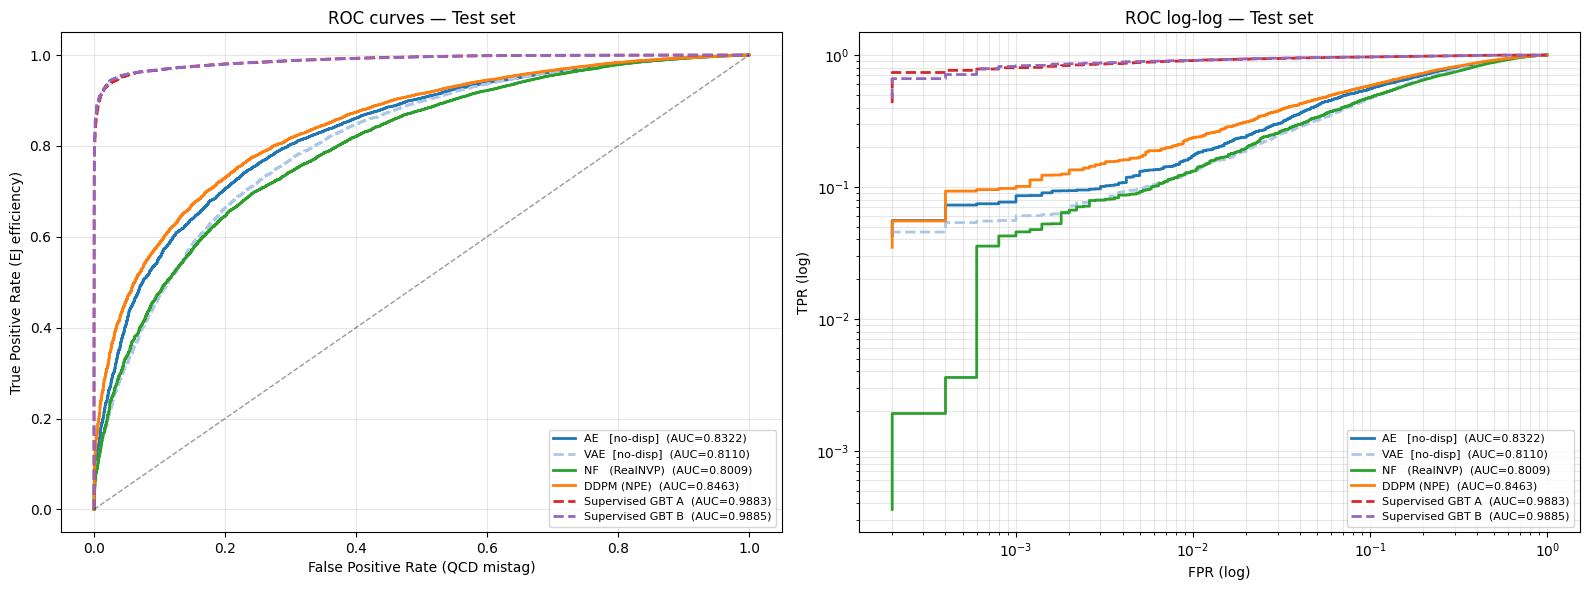

Salvato: roc_curves_all.png


In [11]:
# ── Palette ────────────────────────────────────────────────────────────────────
COLORS = {
    'AE   [no-disp]'   : ('#1f77b4', '-',  'o'),
    'VAE  [no-disp]'   : ('#aec7e8', '--', 's'),
    'NF   (RealNVP)'   : ('#2ca02c', '-',  '^'),
    'DDPM (NPE)'       : ('#ff7f0e', '-',  'D'),
    'Supervised GBT A' : ('#d62728', '--', 'x'),
    'Supervised GBT B' : ('#9467bd', '--', 'x'),
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

roc_data = {}
for name, scores, group in ALL_MODELS:
    fpr, tpr, thr = roc_curve(y_test, scores, pos_label=1)
    roc_auc = auc(fpr, tpr)
    roc_data[name] = (fpr, tpr, thr, roc_auc)
    col, ls, mk = COLORS[name]

    # ── Standard ROC ────────────────────────────────────────────────────────
    axes[0].plot(fpr, tpr, color=col, linestyle=ls, lw=2,
                 label=f'{name}  (AUC={roc_auc:.4f})')

    # ── Log ROC (HEP style) ──────────────────────────────────────────────────
    mask_nz = fpr > 1e-5
    axes[1].plot(fpr[mask_nz], tpr[mask_nz], color=col, linestyle=ls, lw=2,
                 label=f'{name}  (AUC={roc_auc:.4f})')

axes[0].plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
axes[0].set_xlabel('False Positive Rate (QCD mistag)')
axes[0].set_ylabel('True Positive Rate (EJ efficiency)')
axes[0].set_title('ROC curves — Test set')
axes[0].legend(fontsize=8, loc='lower right')
axes[0].grid(True, alpha=0.3)

axes[1].set_xscale('log'); axes[1].set_yscale('log')
axes[1].set_xlabel('FPR (log)')
axes[1].set_ylabel('TPR (log)')
axes[1].set_title('ROC log-log — Test set')
axes[1].legend(fontsize=8, loc='lower right')
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT / 'roc_curves_all.png', dpi=150, bbox_inches='tight')
plt.show()
print('Salvato: roc_curves_all.png')

### 8.1 ROC separata per Gruppo A e Gruppo B

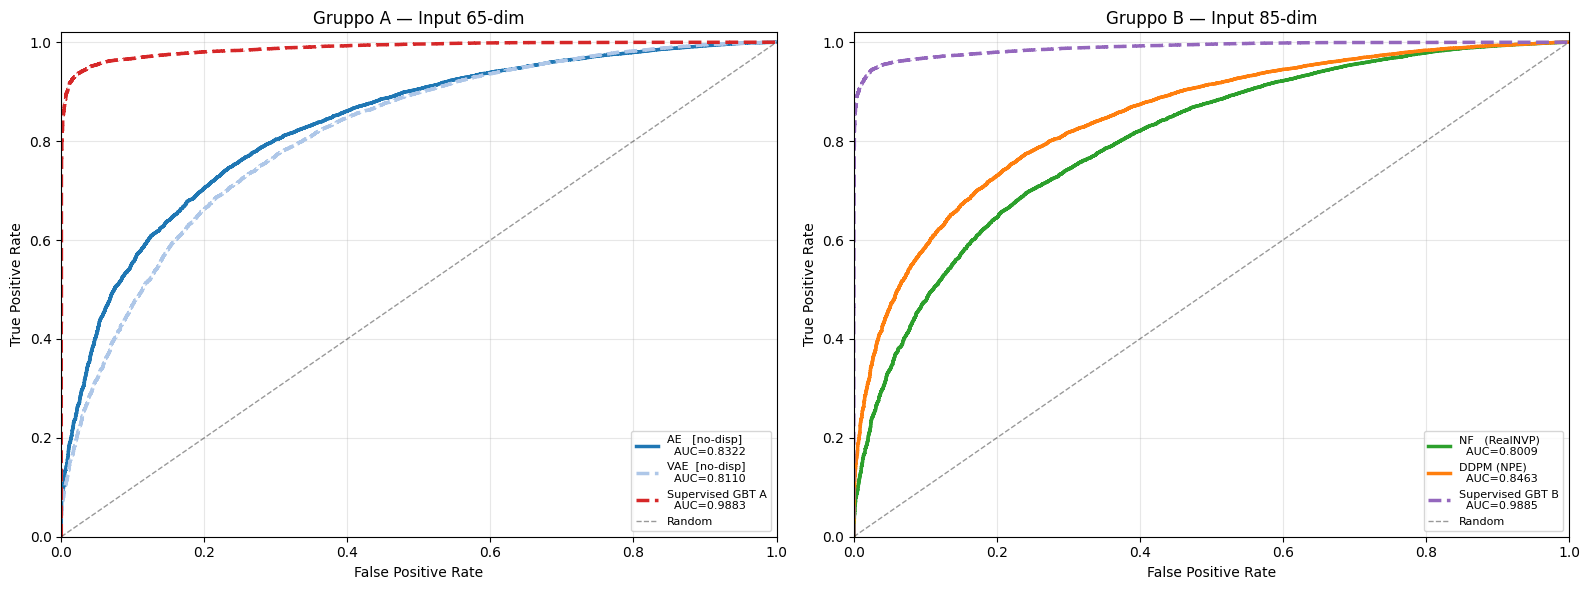

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

GROUPS = {
    'A': [('AE   [no-disp]', scores_ae), ('VAE  [no-disp]', scores_vae),
          ('Supervised GBT A', scores_sup_A)],
    'B': [('NF   (RealNVP)',  scores_nf),  ('DDPM (NPE)',      scores_ddpm),
          ('Supervised GBT B', scores_sup_B)],
}

for ax, (grp, models) in zip(axes, GROUPS.items()):
    for name, scores in models:
        fpr, tpr, _ = roc_curve(y_test, scores, pos_label=1)
        roc_auc = auc(fpr, tpr)
        col, ls, _ = COLORS[name]
        ax.plot(fpr, tpr, color=col, linestyle=ls, lw=2.5,
                label=f'{name}\n  AUC={roc_auc:.4f}')
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.4,label='Random')
    dim = '65' if grp=='A' else '85'
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'Gruppo {grp} — Input {dim}-dim')
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0,1); ax.set_ylim(0,1.02)

plt.tight_layout()
plt.savefig(OUT / 'roc_by_group.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. EJ Efficiency vs QCD Rejection

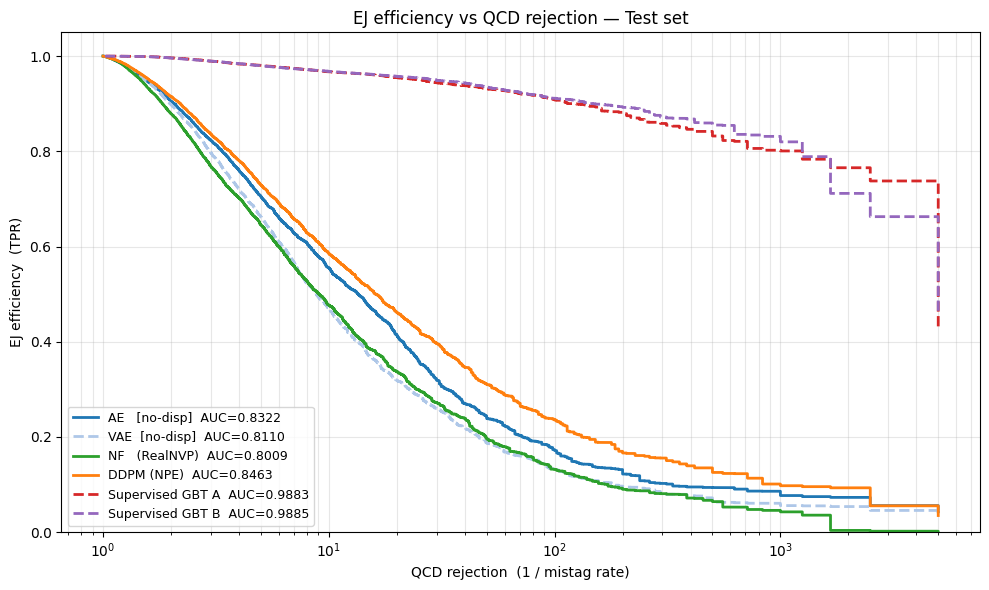

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))

for name, scores, group in ALL_MODELS:
    fpr, tpr, _ = roc_curve(y_test, scores, pos_label=1)
    col, ls, _ = COLORS[name]
    roc_auc = auc(fpr, tpr)
    mask = fpr > 1e-5
    ax.plot(1.0 / fpr[mask], tpr[mask], color=col, linestyle=ls, lw=2,
            label=f'{name}  AUC={roc_auc:.4f}')

ax.set_xscale('log')
ax.set_xlabel('QCD rejection  (1 / mistag rate)')
ax.set_ylabel('EJ efficiency  (TPR)')
ax.set_title('EJ efficiency vs QCD rejection — Test set')
ax.legend(fontsize=9, loc='lower left')
ax.grid(True, which='both', alpha=0.3)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig(OUT / 'efficiency_vs_rejection.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Tabella Riepilogativa delle Metriche

In [14]:
def eff_at_fpr(fpr, tpr, target_fpr):
    idx = np.searchsorted(fpr, target_fpr)
    return float(tpr[min(idx, len(tpr)-1)])

def rejection_at_eff(fpr, tpr, target_tpr):
    idx = np.searchsorted(tpr, target_tpr)
    f = fpr[min(idx, len(fpr)-1)]
    return float(1.0/f) if f > 1e-6 else float('inf')


metrics = {}
rows = []

header = (f"{'Modello':<22s}  {'Gruppo':>6s}  {'Input':>5s}  "
          f"{'AUC':>6s}  "
          f"{'TPR@1%FPR':>10s}  {'TPR@5%FPR':>10s}  {'TPR@10%FPR':>11s}  "
          f"{'Rej@50%TPR':>11s}")
print(header)
print('─' * len(header))

INPUT_DIM_MAP = {
    'AE   [no-disp]'   : ('A', 65),
    'VAE  [no-disp]'   : ('A', 65),
    'NF   (RealNVP)'   : ('B', 85),
    'DDPM (NPE)'       : ('B', 85),
    'Supervised GBT A' : ('A', 65),
    'Supervised GBT B' : ('B', 85),
}

for name, scores, _ in ALL_MODELS:
    fpr, tpr, _ = roc_curve(y_test, scores, pos_label=1)
    roc_auc = auc(fpr, tpr)
    grp, n_dim = INPUT_DIM_MAP[name]
    e1  = eff_at_fpr(fpr, tpr, 0.01)
    e5  = eff_at_fpr(fpr, tpr, 0.05)
    e10 = eff_at_fpr(fpr, tpr, 0.10)
    rej = rejection_at_eff(fpr, tpr, 0.50)
    print(f"  {name:<20s}  {grp:>6s}  {n_dim:>5d}  "
          f"{roc_auc:>6.4f}  "
          f"{e1:>10.3f}  {e5:>10.3f}  {e10:>11.3f}  "
          f"{rej:>11.1f}")
    metrics[name] = dict(group=grp, input_dim=n_dim, auc=round(float(roc_auc),4),
                         eff_1pct=round(e1,4), eff_5pct=round(e5,4),
                         eff_10pct=round(e10,4), rej_at_50pct=round(rej,1))

# Salva JSON
with open(OUT / 'metrics_summary.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print(f'\nSalvato: metrics_summary.json')

Modello                 Gruppo  Input     AUC   TPR@1%FPR   TPR@5%FPR   TPR@10%FPR   Rej@50%TPR
───────────────────────────────────────────────────────────────────────────────────────────────
  AE   [no-disp]             A     65  0.8322       0.171       0.414        0.556         13.5
  VAE  [no-disp]             A     65  0.8110       0.131       0.320        0.470          8.8
  NF   (RealNVP)             B     85  0.8009       0.132       0.337        0.477          9.0
  DDPM (NPE)                 B     85  0.8463       0.235       0.461        0.586         16.1
  Supervised GBT A           A     65  0.9883       0.908       0.955        0.967       5000.0
  Supervised GBT B           B     85  0.9885       0.911       0.958        0.968       5000.0

Salvato: metrics_summary.json


### 10.1 Barplot AUC comparativo

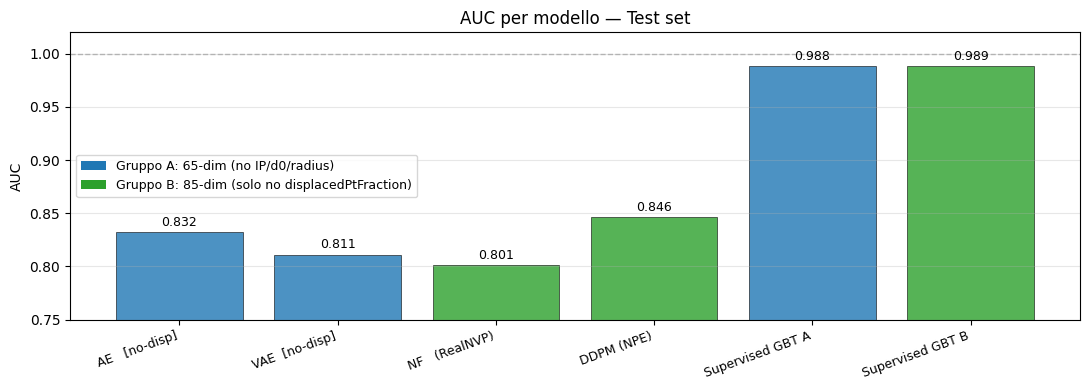

In [15]:
names  = list(metrics.keys())
aucs_v = [metrics[n]['auc'] for n in names]
groups = [metrics[n]['group'] for n in names]
col_map = {'A': '#1f77b4', 'B': '#2ca02c'}
bar_colors = [col_map[g] for g in groups]

fig, ax = plt.subplots(figsize=(11, 4))
bars = ax.bar(range(len(names)), aucs_v, color=bar_colors, alpha=0.8, edgecolor='k', linewidth=0.5)
for bar, v in zip(bars, aucs_v):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.003, f'{v:.3f}',
            ha='center', va='bottom', fontsize=9)
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('AUC')
ax.set_ylim(0.75, 1.02)
ax.axhline(1.0, color='gray', lw=1, ls='--', alpha=0.5)
ax.set_title('AUC per modello — Test set')
# Legenda gruppi
from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor='#1f77b4', label='Gruppo A: 65-dim (no IP/d0/radius)'),
                   Patch(facecolor='#2ca02c', label='Gruppo B: 85-dim (solo no displacedPtFraction)')],
          fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / 'auc_barplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Confronto unsupervised vs supervised — Efficiency gap

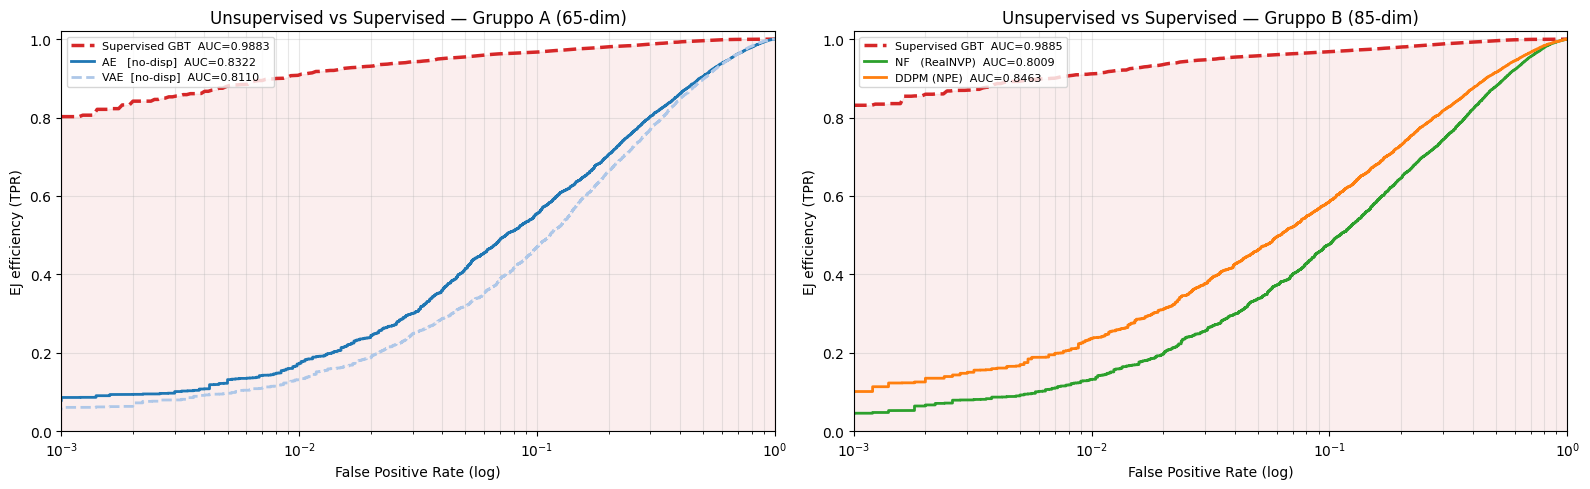

In [16]:
fpr_grid = np.logspace(-3, 0, 200)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, grp in zip(axes, ['A', 'B']):
    models_in_group = [(n, s) for (n, s, g) in ALL_MODELS if g == grp]
    sup_name = f'Supervised GBT {grp}'
    sup_scores = dict(models_in_group)[sup_name]
    fpr_s, tpr_s, _ = roc_curve(y_test, sup_scores, pos_label=1)
    tpr_sup_interp = np.interp(fpr_grid, fpr_s, tpr_s)

    # Fill area supervised
    ax.fill_between(fpr_grid, tpr_sup_interp, alpha=0.08, color='#d62728')
    ax.plot(fpr_grid, tpr_sup_interp, color='#d62728', lw=2.5, ls='--',
            label=f'Supervised GBT  AUC={auc(fpr_s,tpr_s):.4f}')

    for name, scores in models_in_group:
        if 'Supervised' in name: continue
        fpr_u, tpr_u, _ = roc_curve(y_test, scores, pos_label=1)
        roc_auc = auc(fpr_u, tpr_u)
        col, ls, _ = COLORS[name]
        ax.plot(fpr_u, tpr_u, color=col, lw=2, ls=ls,
                label=f'{name}  AUC={roc_auc:.4f}')

    ax.set_xscale('log')
    ax.set_xlabel('False Positive Rate (log)')
    ax.set_ylabel('EJ efficiency (TPR)')
    dim = '65' if grp=='A' else '85'
    ax.set_title(f'Unsupervised vs Supervised — Gruppo {grp} ({dim}-dim)')
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, which='both', alpha=0.3)
    ax.set_xlim(1e-3, 1); ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig(OUT / 'unsup_vs_sup_by_group.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Salvataggio degli score consolidati

In [17]:
np.savez(
    OUT / 'all_scores_comparison.npz',
    scores_ae     = scores_ae,
    scores_vae    = scores_vae,
    scores_nf     = scores_nf,
    scores_ddpm   = scores_ddpm,
    scores_sup_A  = scores_sup_A,
    scores_sup_B  = scores_sup_B,
    y_test        = y_test,
)
print(f'Score salvati in: {OUT / "all_scores_comparison.npz"}')
print(f'Metriche in:      {OUT / "metrics_summary.json"}')

Score salvati in: C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\outputs\task3_comparison\all_scores_comparison.npz
Metriche in:      C:\Users\delco\Desktop\Universita\Ad_M\Dataset-Programs\outputs\task3_comparison\metrics_summary.json


## 13. Riepilogo finale

In [18]:
print('╔' + '═'*70 + '╗')
print('║  TASK 3 — RIEPILOGO COMPARATIVO' + ' '*37 + '║')
print('╠' + '═'*70 + '╣')
print('║  GRUPPO A (65-dim — feature IP/d0/radius rimosse)' + ' '*20 + '║')
for n in ['AE   [no-disp]', 'VAE  [no-disp]', 'Supervised GBT A']:
    m = metrics[n]
    tag = ' ← supervised (upper bound)' if 'Supervised' in n else ''
    print(f'║  {n:<20s}  AUC={m["auc"]:.4f}  TPR@1%={m["eff_1pct"]:.3f}{tag}')
print('╠' + '═'*70 + '╣')
print('║  GRUPPO B (85-dim — solo displacedPtFraction rimossa)' + ' '*16 + '║')
for n in ['NF   (RealNVP)', 'DDPM (NPE)', 'Supervised GBT B']:
    m = metrics[n]
    tag = ' ← supervised (upper bound)' if 'Supervised' in n else ''
    print(f'║  {n:<20s}  AUC={m["auc"]:.4f}  TPR@1%={m["eff_1pct"]:.3f}{tag}')
print('╠' + '═'*70 + '╣')
print('║  NOTE:' + ' '*63 + '║')
print('║  - Supervised ≈ upper bound: conosce le label EJ al training   ║')
print('║  - Gap unsup/sup: misura quanto "costa" non avere le label      ║')
print('║  - Gruppo B > Gruppo A: feature IP/d0/radius aggiungono potere ║')
print('║    discriminante fisicamente motivato per le tracce displaced   ║')
print('╚' + '═'*70 + '╝')
print(f'\nOutput salvati in: {OUT}')

╔══════════════════════════════════════════════════════════════════════╗
║  TASK 3 — RIEPILOGO COMPARATIVO                                     ║
╠══════════════════════════════════════════════════════════════════════╣
║  GRUPPO A (65-dim — feature IP/d0/radius rimosse)                    ║
║  AE   [no-disp]        AUC=0.8322  TPR@1%=0.171
║  VAE  [no-disp]        AUC=0.8110  TPR@1%=0.131
║  Supervised GBT A      AUC=0.9883  TPR@1%=0.908 ← supervised (upper bound)
╠══════════════════════════════════════════════════════════════════════╣
║  GRUPPO B (85-dim — solo displacedPtFraction rimossa)                ║
║  NF   (RealNVP)        AUC=0.8009  TPR@1%=0.132
║  DDPM (NPE)            AUC=0.8463  TPR@1%=0.235
║  Supervised GBT B      AUC=0.9885  TPR@1%=0.911 ← supervised (upper bound)
╠══════════════════════════════════════════════════════════════════════╣
║  NOTE:                                                               ║
║  - Supervised ≈ upper bound: conosce le label EJ al training 